<a href="https://colab.research.google.com/github/michelleabraham-git/Stats_minor/blob/main/Copy_of_CSSL_07_Regularization_and_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

!pip install ISLP
from ISLP import load_data

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c22bf2f30d7e5cc0b8ce853a2c18209d901656b538133268b2ed6783d61b0108
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


THE RIDGECV AND LASSOCV GIVE THE FINAL MODEL DIRECTLY

# Utility functions

In [13]:
# Compute RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Load data

In [14]:
df = load_data('Hitters')

Now lets take a look at the data

In [15]:
print("Shape:", df.shape)
df.head()

Shape: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


We need to convert the categorical values like league, division etc. into numerical values, if we just make it into binary what will we do if we had more than two values. we cant just assign numbers because then that assumes a a hierarchy of 1 being closer to 0, 2 being closer 1 etc. so we do something else.

# Preprocessing
We need to find if there are missing values in the dataset and figure out a way to deal with them.

In [16]:
rows_with_na = df[df.isna().any(axis=1)]
print("\nRows containing NAs:")
rows_with_na


Rows containing NAs:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
15,183,39,3,20,15,11,3,201,42,3,20,16,11,A,W,118,0,0,NaN,A
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,A,W,912,88,9,NaN,A
22,22,10,1,4,2,1,6,84,26,2,9,9,3,A,W,812,84,11,NaN,A
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,A,W,127,221,7,NaN,A
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,N,W,1378,102,8,NaN,N
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,A,E,70,149,12,NaN,A
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,A,E,0,0,0,NaN,A
39,241,61,1,34,12,14,1,241,61,1,34,12,14,N,W,166,172,10,NaN,N
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,N,W,103,84,5,NaN,N


Let's drop the rows with NaN values and split the dataset into train and test.

In [17]:
df = df.dropna().reset_index(drop=True)
target = "Salary"
X = df.drop(columns=[target])
y = df[target]
print(X.shape, y.shape)

# First split: train+val vs test (80% / 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)
# splitting the whole data in train and test- it is the training data which also includes the validation data, basically we are just taking out the test data

# Second split: train vs validation (75% / 25% of remaining 80%)
# This gives: 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=20
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

(263, 19) (263,)
Train size: 157
Validation size: 53
Test size: 53


Now we need to transform the categorical values into numerical values and also scale all the features so that they roughly lie within the same range. If some features are represented using large numbers while others are represented in small numbers, it can skew the error calculcations, similar to what happened when we did polynomial regression.

In [18]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols), # Scales columns containing numerical data using (x-mu)/sigma so that the values have mean 0 and standard deviation 1
        ("cat", OneHotEncoder(drop="first"), categorical_cols) # Encodes categorical values using one hot encoding
    ]
)


In [21]:
# If you want to understand how the OneHotEncoder works, uncomment the below lines of code and try it out
X_1hot = [["East"], ["West"], ["Central"]]

enc = OneHotEncoder(drop="first", sparse_output=False) # Note- The encoder sorts the list of unique categories before encoding
encoded = enc.fit_transform(X_1hot)

print(encoded)

[[1. 0.]
 [0. 1.]
 [0. 0.]]


# Linear regression using OLS

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

# OLS Model
ols_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# 2) Fit on training data
ols_model.fit(X_train_val, y_train_val)

# 3) Predictions
y_train_pred = ols_model.predict(X_train)
y_test_pred  = ols_model.predict(X_test)


ols_test_rmse = rmse(y_test, y_test_pred)

print("OLS Performance:")
print("Train RMSE:", rmse(y_train, y_train_pred))
print("Test RMSE:", rmse(y_test, y_test_pred))

OLS Performance:
Train RMSE: 324.06672222153134
Test RMSE: 309.4980873341895


[359.85914369 359.8144668  359.76491655 359.71003876 359.64935445
 359.58236247 359.5085432  359.42736335 359.33828201 359.240758
 359.13425848 359.01826867 358.89230272 358.7559152  358.60871323
 358.45036856 358.28062946 358.09933185 357.90640944 357.70190252
 357.4859653  357.25887184 357.02102041 356.77293676 356.51527601
 356.24882352 355.97449437 355.69333113 355.4064994  355.11528039
 354.82105969 354.5253118  354.2295799  353.93545104 353.6445272
 353.35839309 353.07858192 352.80654043 352.5435942  352.29091431
 352.04948586 351.82007896 351.60322247 351.39918153 351.20793987
 351.02918889 350.86232551 350.70646103 350.56044283 350.42288958
 350.29223967 350.16681079 350.0448677  349.92469413 349.80466474
 349.68331359 349.55939643 349.43194546 349.30031638 349.1642279
 349.02379448 348.87955203 348.73247559 348.58398688 348.43594888
 348.29064457 348.15073792 348.01921667 347.89931932 347.79445067
 347.70809287 347.64372027 347.60472655 347.59437222 347.61575852
 347.67183199 

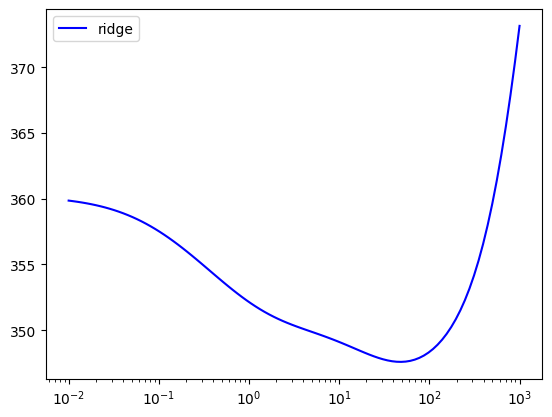

In [27]:
# Define lambdas grid
lambdas = np.logspace(-2, 3, 100)

# 5-fold CV
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

ridge_val_rmse = np.full((num_folds, len(lambdas)), np.inf)


for l_ind, l in enumerate(lambdas):
  fold = 0

  for train_idx, val_idx in kf.split(X_train_val):

    X_train_fold = X_train_val.iloc[train_idx]
    y_train_fold = y_train_val.iloc[train_idx]
    X_val_fold   = X_train_val.iloc[val_idx]
    y_val_fold   = y_train_val.iloc[val_idx]

    # Pipeline: preprocessing + Ridge
    ridge_model = Pipeline([
            ("preprocess", preprocess),
            ("ridge", Ridge(alpha=l, max_iter=10000))
        ])

    ridge_model.fit(X_train_fold, y_train_fold)
    ridge_preds = ridge_model.predict(X_val_fold)

    ridge_val_rmse[fold, l_ind] = rmse(y_val_fold, ridge_preds)

    fold += 1

ridge_mean_rmse = np.mean(ridge_val_rmse, axis=0)

print(ridge_mean_rmse)

# Find best lambda
ridge_best_lambda = lambdas[np.argmin(ridge_mean_rmse)]
print("Best lambda for ridge:", ridge_best_lambda)
print("Best Validation RMSE for ridge:", min(ridge_mean_rmse))



# Plot the lambdas vs mean_rmse for ridge and lasso
plt.figure()
plt.plot(lambdas, ridge_mean_rmse, c="b", label="ridge")

plt.xscale('log')
plt.legend()

# Fit the final model
Now that we have the best lambda values, we can try to fit the whole train+val dataset using these values.

In [28]:
ridge_final_model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=ridge_best_lambda))
])

ridge_final_model.fit(X_train_val, y_train_val)

ridge_test_preds = ridge_final_model.predict(X_test)



print("Test RMSE for OLS:", ols_test_rmse)
print("Test RMSE for Ridge Regression with cross validation:", rmse(y_test, ridge_test_preds))



Test RMSE for OLS: 309.4980873341895
Test RMSE for Ridge Regression with cross validation: 296.1859621013697


Best lambda for ridge: 48.62601580065353
Best Validation RMSE for ridge: 347.5943722166363
Best lambda for lasso: 2.9836472402833403
Best Validation RMSE for lasso: 350.19440206990436


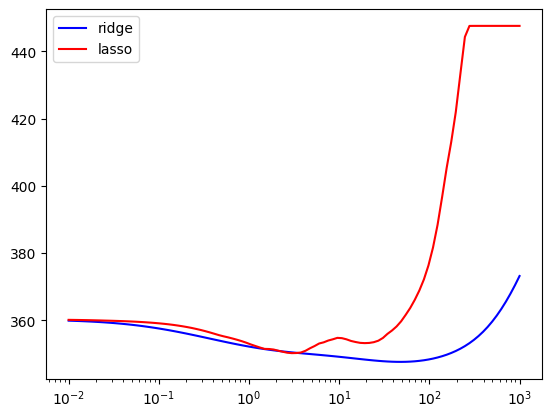

In [30]:
#LASSO
# Define lambdas grid
lambdas = np.logspace(-2, 3, 100)

# 5-fold CV
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lasso_val_rmse
lasso_val_rmse = np.full((num_folds, len(lambdas)), np.inf)

for l_ind, l in enumerate(lambdas):
  fold = 0

  for train_idx, val_idx in kf.split(X_train_val):

    X_train_fold = X_train_val.iloc[train_idx]
    y_train_fold = y_train_val.iloc[train_idx]
    X_val_fold   = X_train_val.iloc[val_idx]
    y_val_fold   = y_train_val.iloc[val_idx]

    # Pipeline: preprocessing + lasso
    lasso_model = Pipeline([
            ("preprocess", preprocess),
            ("lasso", Lasso(alpha=l, max_iter=10000))
        ])

    lasso_model.fit(X_train_fold, y_train_fold)
    lasso_preds = lasso_model.predict(X_val_fold)

    lasso_val_rmse[fold, l_ind] = rmse(y_val_fold, lasso_preds)

    fold += 1

ridge_mean_rmse = np.mean(ridge_val_rmse, axis=0)
lasso_mean_rmse = np.mean(lasso_val_rmse, axis=0)


# Find best lambda for ridge
ridge_best_lambda = lambdas[np.argmin(ridge_mean_rmse)]
print("Best lambda for ridge:", ridge_best_lambda)
print("Best Validation RMSE for ridge:", min(ridge_mean_rmse))

#find best lambda for lasso
lasso_best_lambda = lambdas[np.argmin(lasso_mean_rmse)]
print("Best lambda for lasso:", lasso_best_lambda)
print("Best Validation RMSE for lasso:", min(lasso_mean_rmse))

# Plot the lambdas vs mean_rmse for ridge and lasso
plt.figure()
plt.plot(lambdas, ridge_mean_rmse, c="b", label="ridge")
plt.plot(lambdas, lasso_mean_rmse, c="r", label="lasso") # Changed color for lasso to distinguish

plt.xscale('log')
plt.legend()

In [33]:
#creating the final fit model for the for lasso also
lasso_final_model = Pipeline([
    ("preprocess", preprocess),
    ("lasso", Lasso(alpha=lasso_best_lambda))
])

lasso_final_model.fit(X_train_val, y_train_val)

lasso_test_preds = lasso_final_model.predict(X_test)



print("Test LASSO for OLS:", ols_test_rmse)
print("Test RMSE for LASSO Regression with cross validation:", rmse(y_test, lasso_test_preds))


Test LASSO for OLS: 309.4980873341895
Test LASSO for Ridge Regression with cross validation: 289.88176363442216


SO, here the lasso model is slightly better